# 05 · How complaints change over time

**Important sampling note:** the dataset contains the **80 most recent decisions in each two-month window** (Sep 2024 – Aug 2026).
Every window has the same number of decisions, so counting decisions over time would show a flat line by design.
Instead I look at **how the mix changes**: what share of each window is scams, and what share is upheld.

Why no ARIMA forecast (lesson 22)? ARIMA needs a real volume series with many points. Twelve fixed-size samples aren't that.
The README explains how to get a proper monthly volume series from the Ombudsman's published complaints data if you want to add forecasting.

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make "src" importable when the notebook runs from the notebooks/ folder
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

FIG_DIR = ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold"})
pd.set_option("display.max_colwidth", 120)

In [2]:
from scipy import stats

df = pd.read_csv(ROOT / "data" / "processed" / "decisions_clean.csv", parse_dates=["decision_date", "period_start"])
by_period = df.groupby("period_start").agg(n=("reference", "size"), upheld_rate=("upheld", "mean"),
                                           scam_share=("theme", lambda s: (s == "Scam / APP fraud").mean()))
by_period

,n,upheld_rate,scam_share
period_start,,,
2024-09-01,80,0.3500,0.2500
2024-11-01,80,0.3500,0.2250
2025-01-01,80,0.3875,0.3125
2025-03-01,80,0.2750,0.0875
2025-05-01,80,0.1750,0.3000
2025-07-01,80,0.2625,0.3875
2025-09-01,80,0.2250,0.3875
2025-11-01,80,0.2500,0.2875
2026-01-01,80,0.2500,0.1875


## 1. Upheld rate over time

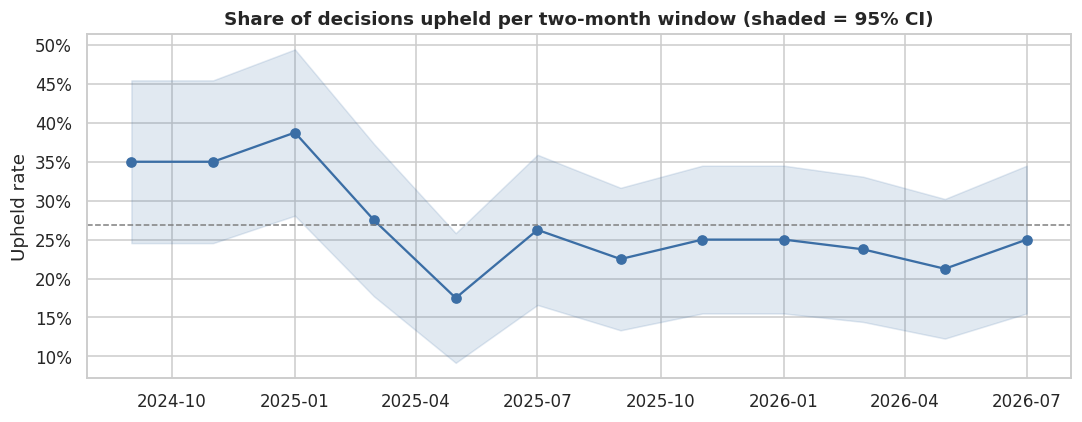

In [3]:
ci = 1.96 * np.sqrt(by_period["upheld_rate"] * (1 - by_period["upheld_rate"]) / by_period["n"])
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(by_period.index, by_period["upheld_rate"], marker="o", color="#3b6ea5")
ax.fill_between(by_period.index, by_period["upheld_rate"] - ci, by_period["upheld_rate"] + ci, alpha=0.15, color="#3b6ea5")
ax.axhline(df["upheld"].mean(), ls="--", color="grey", lw=1)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.set(title="Share of decisions upheld per two-month window (shaded = 95% CI)", ylabel="Upheld rate", xlabel="")
plt.tight_layout(); plt.savefig(FIG_DIR / "09_upheld_rate_over_time.png"); plt.show()

## 2. Is there a real trend? First year vs second year
A chi-square test checks whether the upheld rate differs between the two years by more than chance would explain.

In [4]:
df["year_block"] = np.where(df["decision_date"] < "2025-09-01", "Sep 2024 – Aug 2025", "Sep 2025 – Aug 2026")
table = pd.crosstab(df["year_block"], df["upheld"])
chi2, p, _, _ = stats.chi2_contingency(table)
print(table.rename(columns={0: "not upheld", 1: "upheld"}))
print("\nUpheld rate:", df.groupby("year_block")["upheld"].mean().round(3).to_dict())
print(f"Chi-square p-value: {p:.3f}  ->  {'significant' if p < 0.05 else 'not significant'} at the 5% level")

upheld               not upheld  upheld
year_block                             
Sep 2024 – Aug 2025         336     144
Sep 2025 – Aug 2026         366     114

Upheld rate: {'Sep 2024 – Aug 2025': 0.3, 'Sep 2025 – Aug 2026': 0.238}
Chi-square p-value: 0.035  ->  significant at the 5% level


**Result:** the upheld rate fell from about 30% in the first year to about 24% in the second, and the test says that's unlikely to be chance (p < 0.05).

But is this real, or did the *mix* of complaints change (e.g. more timeshare claims, which rarely win)? The next table compares the upheld rate **within each theme**.

In [5]:
within = pd.crosstab(df["theme"], df["year_block"], values=df["upheld"], aggfunc="mean")
within["n"] = df["theme"].value_counts()
within.sort_values("n", ascending=False).style.format({c: "{:.0%}" for c in within.columns[:2]})

year_block,Sep 2024 – Aug 2025,Sep 2025 – Aug 2026,n
theme,,,
Scam / APP fraud,28%,20%,232
Service & administration,21%,32%,203
Car finance - vehicle quality,73%,59%,85
Irresponsible lending,28%,11%,83
Refund claim (s75 / chargeback),27%,24%,83
Account closure / fraud marker,30%,6%,62
Timeshare / unfair credit (s140A),23%,9%,59
Unauthorised transactions,15%,18%,49
Credit file / debt / defaults,38%,32%,38


The fall shows up **inside most themes** (scams, irresponsible lending, account closures), so it isn't only a mix effect. Several themes have small samples, so treat individual rows with care.

## 3. How the complaint mix is shifting

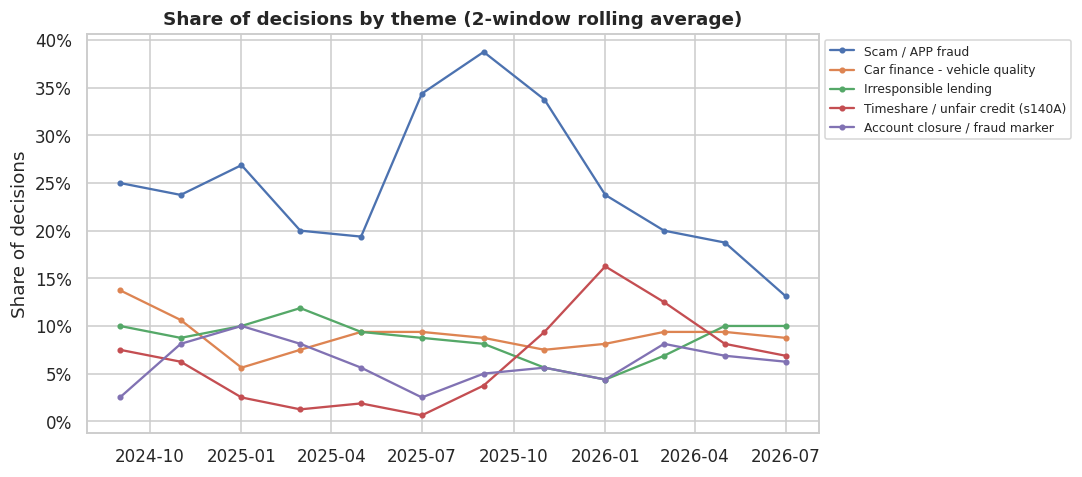

In [6]:
from src.labels import THEME_ORDER
mix = pd.crosstab(df["period_start"], df["theme"], normalize="index")[THEME_ORDER]
main = ["Scam / APP fraud", "Car finance - vehicle quality", "Irresponsible lending",
        "Timeshare / unfair credit (s140A)", "Account closure / fraud marker"]
fig, ax = plt.subplots(figsize=(10, 4.5))
for t in main:
    ax.plot(mix.index, mix[t].rolling(2, min_periods=1).mean(), marker="o", ms=3, label=t)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.set(title="Share of decisions by theme (2-window rolling average)", ylabel="Share of decisions", xlabel="")
ax.legend(fontsize=8, loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout(); plt.savefig(FIG_DIR / "10_theme_mix_over_time.png"); plt.show()

In [7]:
# Compare each theme's share between the two years
share = pd.crosstab(df["theme"], df["year_block"], normalize="columns")
share["change (pts)"] = (share.iloc[:, 1] - share.iloc[:, 0]) * 100
share.sort_values("change (pts)").style.format({share.columns[0]: "{:.1%}", share.columns[1]: "{:.1%}",
                                                "change (pts)": "{:+.1f}"})

year_block,Sep 2024 – Aug 2025,Sep 2025 – Aug 2026,change (pts)
theme,,,
Scam / APP fraud,26.0%,22.3%,-3.8
Mortgage,4.8%,1.2%,-3.5
Irresponsible lending,9.8%,7.5%,-2.3
Unauthorised transactions,5.6%,4.6%,-1.0
"Mis-selling, fees & charges",4.4%,3.3%,-1.0
Car finance - vehicle quality,9.2%,8.5%,-0.6
Refund claim (s75 / chargeback),8.5%,8.8%,+0.2
Account closure / fraud marker,6.2%,6.7%,+0.4
Service & administration,20.0%,22.3%,+2.3


## What I learned
- **Fewer complaints are going the customer's way**: the upheld rate fell from ~30% to ~24% between the two years, and the fall appears within most themes, not just because the mix changed.
- **Scams are the largest theme overall but their share fell** in the 2026 windows, while timeshare/s140A decisions rose. That matches a wave of claims-firm timeshare cases reaching final decision.
- Any shift in the theme mix needs to be read against the sampling: each window is the last few days of decisions,
  so a single day with many similar cases (e.g. a batch of timeshare decisions) can move a window's share.
- For a real volume trend and an ARIMA forecast, the next step is the Ombudsman's half-yearly complaints data (new cases per firm), which is a proper time series.